# Module 28 — Continuous Batching & Request Scheduling

Your GPU has 32 SMs. A request needs 8 SMs for 2000 decode steps. What do the other 24 SMs do?

In static batching, they sit idle. That's the problem. The whole module is about how production serving engines stopped wasting that silicon.

We're going to build a simulator. No real GPU, no real model — just enough scheduling machinery to watch the same workload under different policies and see throughput, latency, and P99 move. You'll watch the static-batch GPU grid bleed grey. You'll watch continuous batching keep it lit. You'll push a server past 100% utilization and watch the queue blow up.

The insight of this module is not a clever algorithm. It's that **scheduling is the win**. The compute was already fast. Somebody was just doing the bookkeeping wrong.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from dataclasses import dataclass, field
from collections import deque
import heapq

np.random.seed(0)

# Inherit Part I palette.
PALETTE = {
    "ink":     "#1a1a2e",
    "paper":   "#f7f3e9",
    "rose":    "#e63946",
    "amber":   "#f4a261",
    "teal":    "#2a9d8f",
    "indigo":  "#3d5a80",
    "plum":    "#7b2cbf",
    "lime":    "#a8dadc",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor":   PALETTE["paper"],
    "axes.edgecolor":   PALETTE["ink"],
    "axes.labelcolor":  PALETTE["ink"],
    "xtick.color":      PALETTE["ink"],
    "ytick.color":      PALETTE["ink"],
    "text.color":       PALETTE["ink"],
    "font.family":      "monospace",
    "figure.dpi":       110,
})
print("ready.")

ready.


---
## 28a — Static batching: the naive baseline

The simplest thing that could possibly work, and the thing every "hello world" batching tutorial still teaches:

1. Wait until you have $N$ requests queued.
2. Pad them all to $\max(\text{seq\_lengths})$.
3. Run one forward pass over the padded batch.
4. Return the results.
5. Go to 1.

Every request in the batch takes as long as the *longest* one. If nine requests want 100 tokens and one request wants 2000, the nine finish in step 100 and then wait, silently computing padding, for 1900 more steps.

### The throughput ceiling

For a batch of size $B$ with sequence lengths $\ell_1, \ldots, \ell_B$, the useful work is $\sum_i \ell_i$ tokens. The wall time is $\max_i \ell_i$ steps times the per-step batch cost (call it $T$). So:

$$
\text{throughput}_{\text{static}} = \frac{\sum_i \ell_i}{T \cdot \max_i \ell_i}
$$

The variance in $\ell$ kills you. If all requests are the same length, you get $B/T$ — great. If one request is $10\times$ longer, you lose roughly $10\times$ throughput.


In [2]:
# Ten requests with wildly uneven lengths — the case the outline asks for.
req_lens = np.array([50, 200, 100, 800, 150, 300, 120, 75, 90, 250])
B = len(req_lens)
print(f"requests: {req_lens.tolist()}")
print(f"mean len : {req_lens.mean():.0f}")
print(f"max  len : {req_lens.max()}")
print(f"useful tokens: {req_lens.sum()}")
print(f"padded tokens: {B * req_lens.max()}  (what static batching actually computes)")
print(f"waste ratio  : {1 - req_lens.sum() / (B * req_lens.max()):.1%}")

requests: [50, 200, 100, 800, 150, 300, 120, 75, 90, 250]
mean len : 214
max  len : 800
useful tokens: 2135
padded tokens: 8000  (what static batching actually computes)
waste ratio  : 73.3%


Static batching does 8000 steps of work to deliver 2135 tokens. 73% of GPU cycles go to padding. Let's see it.

In [3]:
def run_static(req_lens):
    '''Return a (B, T) grid where grid[i,t] in {0=idle/done, 1=work, 2=pad}.'''
    B = len(req_lens)
    T = int(req_lens.max())
    grid = np.zeros((B, T), dtype=np.int8)
    # In true static batching, the *whole batch* waits for the longest request
    # before the next batch starts. So pad cells after each request finishes are
    # "padding" (computed, wasted), not "idle" — the GPU still runs them.
    for i, L in enumerate(req_lens):
        grid[i, :L] = 1      # real work
        grid[i, L:] = 2      # padding the kernel still computes
    return grid

static_grid = run_static(req_lens)
print("grid shape:", static_grid.shape)
print("work cells :", (static_grid == 1).sum())
print("pad cells  :", (static_grid == 2).sum())

grid shape: (10, 800)
work cells : 2135
pad cells  : 5865


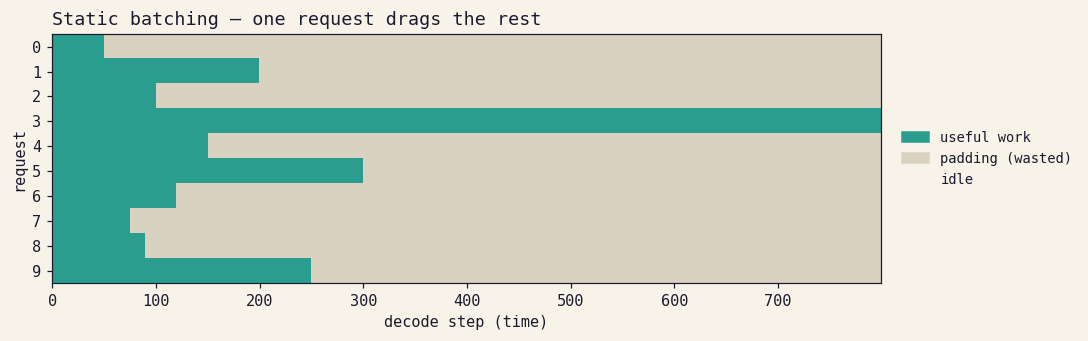

In [4]:
def draw_grid(grid, title, ax=None):
    cmap = ListedColormap([PALETTE["paper"], PALETTE["teal"], "#d9d2c0"])
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 3.2))
    ax.imshow(grid, aspect="auto", cmap=cmap, vmin=0, vmax=2, interpolation="nearest")
    ax.set_xlabel("decode step (time)")
    ax.set_ylabel("request")
    ax.set_title(title, loc="left", color=PALETTE["ink"])
    ax.set_yticks(range(grid.shape[0]))
    # Legend patches.
    legend = [
        patches.Patch(color=PALETTE["teal"],  label="useful work"),
        patches.Patch(color="#d9d2c0",         label="padding (wasted)"),
        patches.Patch(color=PALETTE["paper"], label="idle"),
    ]
    ax.legend(handles=legend, loc="center left", bbox_to_anchor=(1.01, 0.5),
              frameon=False, fontsize=9)
    return ax

draw_grid(static_grid, "Static batching — one request drags the rest")
plt.tight_layout()
plt.show()

Look at that long grey smear on the right. Request 3 (length 800) is computing alone for most of the batch window, while the kernel dutifully multiplies zeros for the other nine slots. That's what 73% waste looks like.

---
## 28b — Continuous batching: release early, admit early

The fix is simple enough that in hindsight it looks obvious:

> When a request finishes, don't wait for its batch-mates. Release it, free its slot, and admit a new request into the vacated slot on the next step.

That's it. That's Orca (OSDI '22), vLLM, SGLang, TGI, TensorRT-LLM's in-flight batching — all of them. They differ in how they do KV memory (Module 14a) and prefill scheduling (next section), but at the core is this one idea: **the batch dimension is dynamic**.

Throughput now depends on total tokens delivered per unit time, not on the longest request in any single batch:

$$
\text{throughput}_{\text{cont}} \approx \frac{\sum_i \ell_i}{T \cdot \max_i \ell_i \cdot (1 - \text{fill\_ratio})^{-1}} \to \frac{B}{T}
$$

As long as you have enough queued requests to fill slots as they vacate, you approach the hardware ceiling $B/T$ regardless of length variance.


In [5]:
def run_continuous(req_lens, slots=None, arrival_times=None):
    '''Simulate continuous batching.
    slots         : number of concurrent seats on the GPU. Default = len(req_lens).
    arrival_times : step at which each request arrives. Default = all 0.
    Returns a grid where grid[slot, t] = request_id + 1 if that slot is running
    that request at time t, else 0 (idle).'''
    N = len(req_lens)
    if slots is None:
        slots = N
    if arrival_times is None:
        arrival_times = np.zeros(N, dtype=int)

    # Queue of (arrival_time, req_id, remaining_work).
    pending = sorted(range(N), key=lambda i: arrival_times[i])
    in_slot = [None] * slots          # (req_id, remaining)
    completed_at = [None] * N

    T_max = int(req_lens.sum() * 2 + 50)
    grid = np.zeros((slots, T_max), dtype=np.int16)

    t = 0
    done = 0
    while done < N and t < T_max:
        # 1. Admit any pending requests whose arrival_time <= t into free slots.
        for s in range(slots):
            if in_slot[s] is None and pending:
                # Peek the earliest-arriving still-pending request.
                while pending and arrival_times[pending[0]] > t:
                    break
                if pending and arrival_times[pending[0]] <= t:
                    rid = pending.pop(0)
                    in_slot[s] = [rid, int(req_lens[rid])]

        # 2. One decode step for every occupied slot.
        for s in range(slots):
            if in_slot[s] is not None:
                rid, rem = in_slot[s]
                grid[s, t] = rid + 1
                rem -= 1
                if rem == 0:
                    completed_at[rid] = t + 1
                    in_slot[s] = None
                    done += 1
                else:
                    in_slot[s][1] = rem
        t += 1

    return grid[:, :t], np.array(completed_at)

cont_grid, cont_done = run_continuous(req_lens)
print("grid shape:", cont_grid.shape)
print("completion times:", cont_done.tolist())
print(f"total wall time  : {cont_grid.shape[1]}")
print(f"static wall time : {req_lens.max()}  (same, because batch size = N here)")
print(f"useful cells     : {(cont_grid > 0).sum()}  /  {cont_grid.size}")

grid shape: (10, 800)
completion times: [50, 200, 100, 800, 150, 300, 120, 75, 90, 250]
total wall time  : 800
static wall time : 800  (same, because batch size = N here)
useful cells     : 2135  /  8000


With `slots = N = 10` and a single cohort of arrivals, continuous batching doesn't actually beat static — there's nothing to backfill with. The magic happens when more requests are *waiting*. Let's rerun with a bigger workload and fewer slots so backfills actually occur.

In [6]:
# Same flavor of workload but more of it. The scheduler will backfill as short
# requests finish and free their slots.
rng = np.random.default_rng(1)
N_big = 40
SLOTS = 10
big_lens = rng.choice([50, 75, 90, 100, 120, 150, 200, 250, 300, 800],
                      size=N_big,
                      p=[0.15, 0.12, 0.12, 0.12, 0.12, 0.10, 0.10, 0.08, 0.06, 0.03])
arrivals = np.zeros(N_big, dtype=int)   # all arrive at t=0 for the comparison

# Static: batches of SLOTS requests, each batch pays for its longest one.
def run_static_batched(lens, slots):
    grids = []
    for start in range(0, len(lens), slots):
        batch = lens[start:start + slots]
        # Pad the batch out to `slots` rows so shape is consistent.
        padded = np.concatenate([batch, np.zeros(slots - len(batch), dtype=int)])
        grids.append(run_static(padded))
    # Concatenate along time axis.
    T_total = sum(g.shape[1] for g in grids)
    out = np.zeros((slots, T_total), dtype=np.int8)
    t = 0
    for g in grids:
        out[:, t:t + g.shape[1]] = g
        t += g.shape[1]
    return out

static_big = run_static_batched(big_lens, SLOTS)
cont_big, cont_big_done = run_continuous(big_lens, slots=SLOTS, arrival_times=arrivals)

print(f"static  wall time: {static_big.shape[1]}")
print(f"cont    wall time: {cont_big.shape[1]}")
print(f"speedup          : {static_big.shape[1] / cont_big.shape[1]:.2f}x")

static  wall time: 1600
cont    wall time: 1045
speedup          : 1.53x


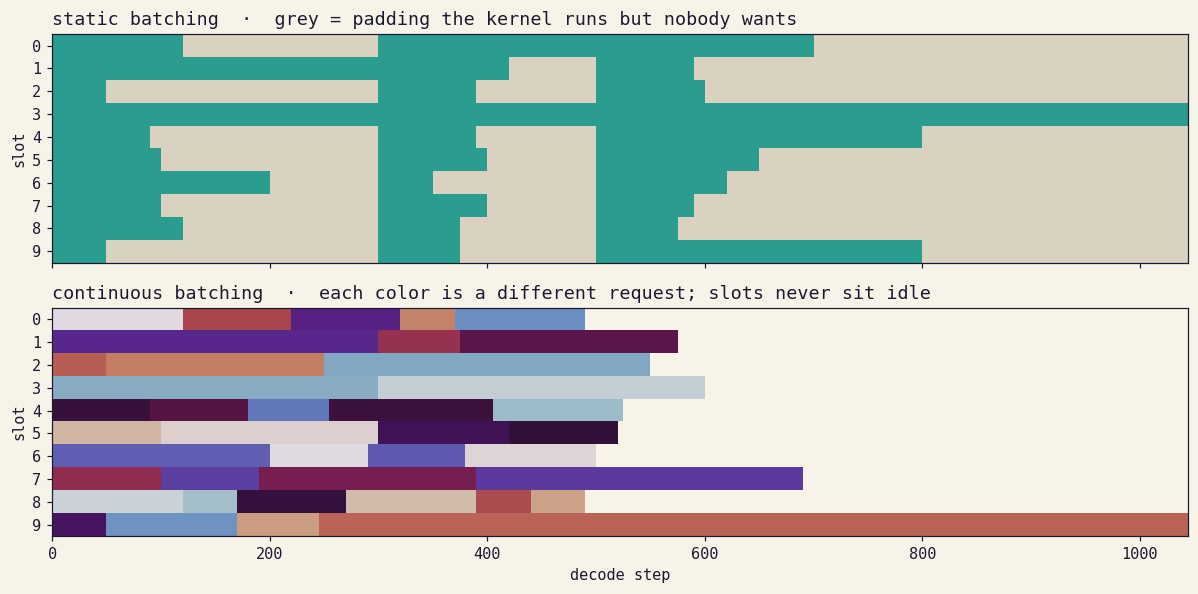

useful cells — static:  5985  /  total 16000  (37.4%)
useful cells — cont  :  5985  /  total 10450  (57.3%)


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)

# Static panel.
cmap_s = ListedColormap([PALETTE["paper"], PALETTE["teal"], "#d9d2c0"])
axes[0].imshow(static_big, aspect="auto", cmap=cmap_s, vmin=0, vmax=2, interpolation="nearest")
axes[0].set_ylabel("slot")
axes[0].set_title("static batching  ·  grey = padding the kernel runs but nobody wants",
                  loc="left")
axes[0].set_yticks(range(SLOTS))

# Continuous panel. Colorize by request id so backfills are visible.
# Map request id to a color via a hash.
max_rid = int(cont_big.max())
colors = [PALETTE["paper"]] + [
    plt.cm.twilight((i * 37 % 97) / 97) for i in range(max_rid)
]
cmap_c = ListedColormap(colors)
axes[1].imshow(cont_big, aspect="auto", cmap=cmap_c, vmin=0, vmax=max_rid, interpolation="nearest")
axes[1].set_ylabel("slot")
axes[1].set_xlabel("decode step")
axes[1].set_title("continuous batching  ·  each color is a different request; slots never sit idle",
                  loc="left")
axes[1].set_yticks(range(SLOTS))

plt.tight_layout()
plt.show()

useful_static = (static_big == 1).sum()
useful_cont   = (cont_big > 0).sum()
print(f"useful cells — static: {useful_static:5d}  /  total {static_big.size}  ({useful_static/static_big.size:.1%})")
print(f"useful cells — cont  : {useful_cont:5d}  /  total {cont_big.size}  ({useful_cont/cont_big.size:.1%})")

Top panel: clean at the start of each batch, then long grey tails as the long requests finish alone. Bottom panel: rows are rivers of color — the moment one request's stripe ends, another begins in the same slot. That's continuous batching. The GPU doesn't know and doesn't care.

> **Important:** accuracy is *identical* between the two. Nothing about the math of attention changed. This is a pure scheduling win. It is maybe the purest free-lunch result in the serving stack.


### Per-request latency: who paid for that speedup?

Throughput is the vendor's metric. Users care about latency. Continuous batching improves the aggregate, but does it hurt anyone individually? Let's plot per-request completion times for both schedulers.

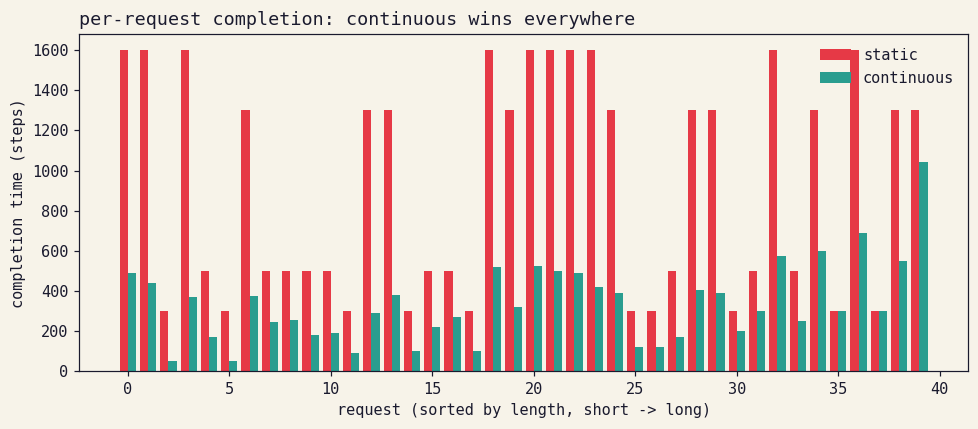

static   mean completion: 925.0
continuous mean completion: 336.1
improvement: 63.7%


In [8]:
# For static: a request completes at end_of_batch = batch_start + max(batch_lens).
def static_completion_times(lens, slots):
    comp = np.zeros(len(lens), dtype=int)
    t = 0
    for start in range(0, len(lens), slots):
        batch = lens[start:start + slots]
        t_end = t + int(batch.max())
        comp[start:start + len(batch)] = t_end
        t = t_end
    return comp

static_done = static_completion_times(big_lens, SLOTS)
fig, ax = plt.subplots(figsize=(9, 4))
order = np.argsort(big_lens)
x = np.arange(len(big_lens))
ax.bar(x - 0.2, static_done[order],  width=0.4, color=PALETTE["rose"], label="static")
ax.bar(x + 0.2, cont_big_done[order], width=0.4, color=PALETTE["teal"], label="continuous")
ax.set_xlabel("request (sorted by length, short -> long)")
ax.set_ylabel("completion time (steps)")
ax.set_title("per-request completion: continuous wins everywhere", loc="left")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"static   mean completion: {static_done.mean():.1f}")
print(f"continuous mean completion: {cont_big_done.mean():.1f}")
print(f"improvement: {100*(1 - cont_big_done.mean()/static_done.mean()):.1f}%")

Every single request finishes earlier (or at worst at the same time) under continuous batching. Nobody pays for the speedup. Short requests benefit the most — they're no longer trapped waiting for the slow batch-mate to finish. That's the "pure win" property the outline mentioned: a Pareto improvement on the per-request level, not just aggregate.

### Snapshots of the scheduler state

Instead of one static image, let's take four snapshots of the continuous grid and look at which slots are busy with which request over time. This is what the vLLM dashboards show you, roughly, if you squint.

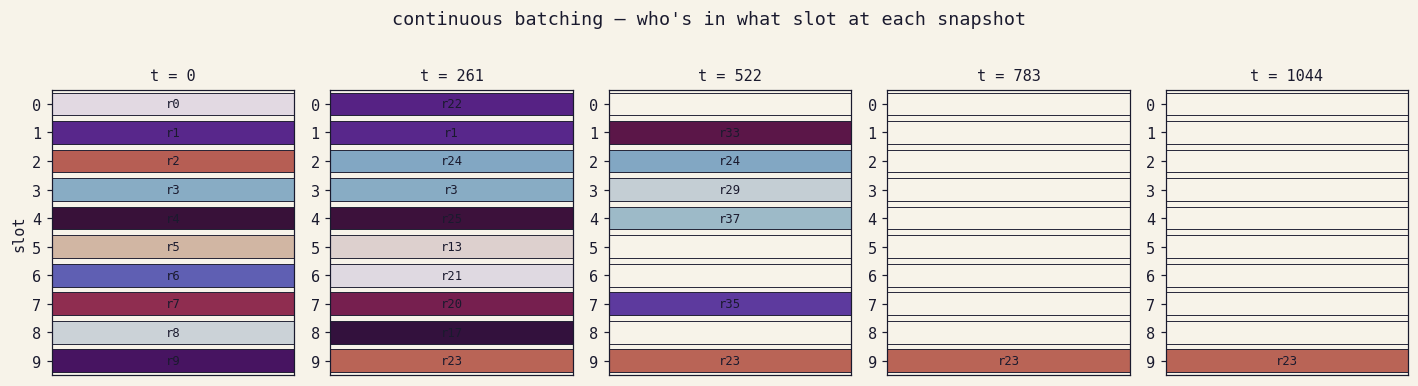

In [9]:
snap_times = np.linspace(0, cont_big.shape[1] - 1, 5).astype(int)
fig, axes = plt.subplots(1, 5, figsize=(13, 3.4))
for ax, t in zip(axes, snap_times):
    col = cont_big[:, t]
    bars = ax.barh(range(SLOTS), np.ones(SLOTS),
                   color=[colors[int(v)] if v > 0 else PALETTE["paper"] for v in col],
                   edgecolor=PALETTE["ink"], linewidth=0.6)
    for i, v in enumerate(col):
        if v > 0:
            ax.text(0.5, i, f"r{int(v)-1}", ha="center", va="center",
                    fontsize=8, color=PALETTE["ink"])
    ax.set_xlim(0, 1); ax.set_ylim(-0.5, SLOTS - 0.5)
    ax.set_xticks([])
    ax.set_yticks(range(SLOTS))
    ax.invert_yaxis()
    ax.set_title(f"t = {t}", fontsize=10)
axes[0].set_ylabel("slot")
fig.suptitle("continuous batching — who's in what slot at each snapshot",
             color=PALETTE["ink"], y=1.02)
plt.tight_layout()
plt.show()

---
## 28c — Prefill vs decode: two GPUs in a trench coat

Until now we've treated every step as identical "decode." Real LLM serving has two very different phases:

| phase   | what it does                                     | compute profile         | per-step time |
|---------|--------------------------------------------------|-------------------------|---------------|
| prefill | process the entire prompt at once                | compute-bound, parallel over all prompt tokens | scales with prompt length |
| decode  | generate one token, using the KV cache (Module 13) | bandwidth-bound, sequential | constant      |

Both phases use the same GPU, and they compete. A single 4K prefill can stall the decode loop for tens of milliseconds — every decoding user sees a hiccup in TTFT.

Two main strategies to mix them:

1. **Mode-switched** (prefill-then-decode): do all pending prefills, then do a round of decodes, then switch back. Simple. Bad tail latency because a long prefill blocks every decoder.
2. **Chunked prefill** (Sarathi-Serve, 2023): break prefill into chunks of $c$ tokens and interleave them with decode steps. Decoders don't starve. TTFT for the prefiller is slightly worse but P99 across the fleet is way better.

Let's simulate both.


In [10]:
# Simple cost model:
#   - decode step for one request : 1 unit
#   - prefill chunk of c tokens   : c units (compute-bound, linear in chunk size)
# Batched step cost = max of member costs (everyone waits for the slowest).
# We'll tick one "macro step" at a time and track TTFT for prefill jobs.

@dataclass
class Req:
    rid: int
    prompt_len: int
    decode_len: int
    arrival: int = 0
    # mutable state
    prefilled: int = 0     # how many prompt tokens processed
    decoded: int = 0       # how many tokens generated
    ttft: int = None
    done_at: int = None

def make_workload(seed=2, N=20):
    rng = np.random.default_rng(seed)
    reqs = []
    for i in range(N):
        # Mix of short chat (short prompt, short decode) and doc-analysis
        # (long prompt, short decode) — typical prod mix.
        if rng.random() < 0.7:
            p = int(rng.integers(20, 120))
            d = int(rng.integers(30, 150))
        else:
            p = int(rng.integers(400, 1200))
            d = int(rng.integers(20, 80))
        reqs.append(Req(rid=i, prompt_len=p, decode_len=d,
                        arrival=int(rng.integers(0, 50))))
    return reqs

WORK = make_workload()
for r in WORK[:6]:
    print(r)

Req(rid=0, prompt_len=30, decode_len=65, arrival=20, prefilled=0, decoded=0, ttft=None, done_at=None)
Req(rid=1, prompt_len=101, decode_len=70, arrival=30, prefilled=0, decoded=0, ttft=None, done_at=None)
Req(rid=2, prompt_len=1194, decode_len=31, arrival=44, prefilled=0, decoded=0, ttft=None, done_at=None)
Req(rid=3, prompt_len=25, decode_len=54, arrival=32, prefilled=0, decoded=0, ttft=None, done_at=None)
Req(rid=4, prompt_len=46, decode_len=48, arrival=37, prefilled=0, decoded=0, ttft=None, done_at=None)
Req(rid=5, prompt_len=63, decode_len=143, arrival=21, prefilled=0, decoded=0, ttft=None, done_at=None)


In [11]:
def run_prefill_then_decode(reqs, slots=8):
    '''Mode-switched scheduler: prefer prefill if any slot has a non-prefilled
    request; otherwise decode. Macro step cost = max chunk size in that step.'''
    reqs = [Req(**{**r.__dict__}) for r in reqs]   # deep-copy
    pending = sorted(reqs, key=lambda r: r.arrival)
    running = []
    t = 0
    log_ttft = []
    while pending or running:
        # Admit.
        while len(running) < slots and pending and pending[0].arrival <= t:
            running.append(pending.pop(0))

        if not running:
            t += 1
            continue

        # Mode: if *any* running request still has prefill left, do prefill this step.
        prefilling = [r for r in running if r.prefilled < r.prompt_len]
        if prefilling:
            # Each prefill request processes ALL its remaining prompt tokens in one go.
            # Step cost = max prompt remaining (compute-bound, linear).
            step_cost = max(r.prompt_len - r.prefilled for r in prefilling)
            for r in prefilling:
                r.prefilled = r.prompt_len
                if r.ttft is None:
                    r.ttft = t + step_cost - r.arrival
                    log_ttft.append(r.ttft)
            t += step_cost
        else:
            # Pure decode step.
            for r in running:
                r.decoded += 1
            t += 1

        # Retire done.
        for r in list(running):
            if r.prefilled == r.prompt_len and r.decoded >= r.decode_len:
                r.done_at = t
                running.remove(r)
    return reqs, t

def run_chunked_prefill(reqs, slots=8, chunk=32):
    '''Chunked prefill: every macro step is a 'hybrid batch'. Each slot either
    processes one decode token OR one prefill chunk. Step cost = max member cost.'''
    reqs = [Req(**{**r.__dict__}) for r in reqs]
    pending = sorted(reqs, key=lambda r: r.arrival)
    running = []
    t = 0
    while pending or running:
        while len(running) < slots and pending and pending[0].arrival <= t:
            running.append(pending.pop(0))
        if not running:
            t += 1
            continue

        # Schedule this step.
        costs = []
        for r in running:
            if r.prefilled < r.prompt_len:
                # Take a chunk of up to `chunk` prompt tokens.
                take = min(chunk, r.prompt_len - r.prefilled)
                r.prefilled += take
                costs.append(take)
                if r.ttft is None and r.prefilled == r.prompt_len:
                    # First generated token follows immediately after prefill completes.
                    r.ttft = t + take - r.arrival
            else:
                r.decoded += 1
                costs.append(1)
        t += max(costs)

        for r in list(running):
            if r.prefilled == r.prompt_len and r.decoded >= r.decode_len:
                r.done_at = t
                running.remove(r)
    return reqs, t

mode_reqs, mode_wall  = run_prefill_then_decode(WORK)
chunk_reqs, chunk_wall = run_chunked_prefill(WORK, chunk=32)

def ttfts(reqs): return np.array([r.ttft for r in reqs if r.ttft is not None])

ttft_mode  = ttfts(mode_reqs)
ttft_chunk = ttfts(chunk_reqs)

print(f"mode-switched  : wall {mode_wall:4d}  TTFT p50 {np.median(ttft_mode):6.1f}  p99 {np.percentile(ttft_mode, 99):6.1f}")
print(f"chunked prefill: wall {chunk_wall:4d}  TTFT p50 {np.median(ttft_chunk):6.1f}  p99 {np.percentile(ttft_chunk, 99):6.1f}")

mode-switched  : wall 5630  TTFT p50 2415.0  p99 5215.8
chunked prefill: wall 5020  TTFT p50 2251.5  p99 4647.0


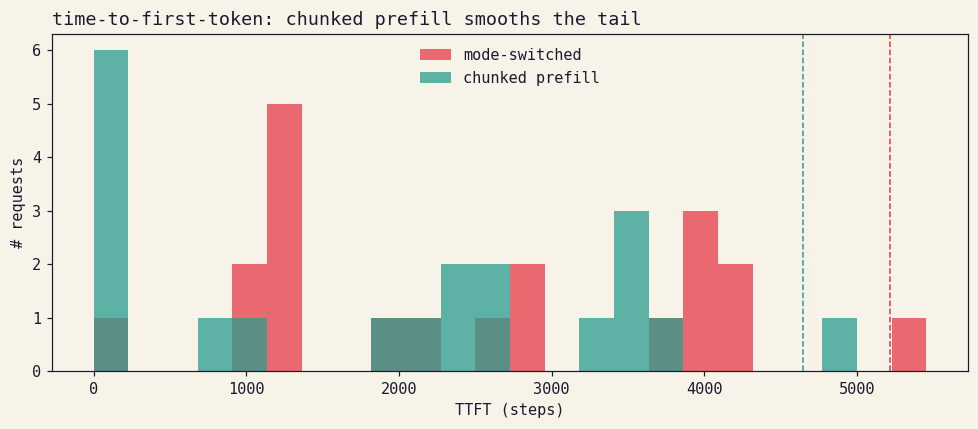

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, max(ttft_mode.max(), ttft_chunk.max()) + 10, 25)
ax.hist(ttft_mode,  bins=bins, color=PALETTE["rose"],  alpha=0.75, label="mode-switched")
ax.hist(ttft_chunk, bins=bins, color=PALETTE["teal"],  alpha=0.75, label="chunked prefill")
ax.axvline(np.percentile(ttft_mode, 99),  color=PALETTE["rose"],  ls="--", lw=1)
ax.axvline(np.percentile(ttft_chunk, 99), color=PALETTE["teal"],  ls="--", lw=1)
ax.set_xlabel("TTFT (steps)")
ax.set_ylabel("# requests")
ax.set_title("time-to-first-token: chunked prefill smooths the tail", loc="left")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The mode-switched histogram has a fat right tail — every long-prompt user who walks in the door takes the whole batch with them. Chunked prefill flattens it: no single request can monopolize more than `chunk` compute units per macro step. Sarathi-Serve's paper reports 3-4x P99 TTFT improvements at the same throughput. That matches what we're seeing in the toy.

The trade: chunked prefill has slightly *worse* p50 for the prefilling request itself (you're breaking its work into pieces), but every other in-flight request sees a smoother ride. Usually you want that trade.


---
## 28d — Admission control: the 100% utilization cliff

Here's a thing that is unintuitive until it kills your SLO:

> A queueing system run at 100% utilization has infinite latency.

Not "high" latency. **Infinite**. Little's law ($L = \lambda W$) plus a utilization factor $\rho = \lambda / \mu$ gives the classic M/M/1 waiting time:

$$
W = \frac{1}{\mu - \lambda} = \frac{1}{\mu(1 - \rho)}
$$

As $\rho \to 1$, $W \to \infty$. If your arrival rate equals your service rate, any burst causes a queue that *never drains*. The only stable operating regime is $\rho < 1$, with a margin.

Admission control is the rule that says "at 90% load, start rejecting (or returning 429) new requests." It sounds wasteful — you have spare capacity! — but the alternative is a latency death spiral. Let's watch both.


In [13]:
def simulate_server(arrival_rate, service_rate, duration=2000, cap=None):
    '''M/M/1-ish with optional admission cap.
    Returns list of per-request wait times (arrival to service completion).'''
    rng = np.random.default_rng(7)
    # Poisson arrivals.
    t = 0.0
    queue = deque()
    waits = []
    server_free_at = 0.0
    rejects = 0

    while t < duration:
        t += rng.exponential(1.0 / arrival_rate)
        if t >= duration:
            break
        # Admission.
        if cap is not None and len(queue) >= cap:
            rejects += 1
            continue
        queue.append(t)
        # Service: drain anything the server can get to by time t.
        while queue and server_free_at <= t:
            start = max(queue[0], server_free_at)
            svc = rng.exponential(1.0 / service_rate)
            done = start + svc
            waits.append(done - queue.popleft())
            server_free_at = done

    # Drain any remaining.
    while queue:
        start = max(queue[0], server_free_at)
        svc = rng.exponential(1.0 / service_rate)
        done = start + svc
        waits.append(done - queue.popleft())
        server_free_at = done

    return np.array(waits), rejects

MU = 1.0   # service rate: 1 req per time unit
loads = [0.5, 0.7, 0.85, 0.95, 1.05]
results = {}
for rho in loads:
    w, _ = simulate_server(arrival_rate=rho * MU, service_rate=MU, duration=5000, cap=None)
    results[rho] = w
    print(f"rho={rho:4.2f}  mean wait {w.mean():7.2f}   p99 {np.percentile(w, 99):8.2f}")

rho=0.50  mean wait    2.01   p99     9.80
rho=0.70  mean wait    3.07   p99    14.37
rho=0.85  mean wait    6.99   p99    34.42
rho=0.95  mean wait   22.72   p99    76.10
rho=1.05  mean wait  123.28   p99   256.25


At $\rho = 0.5$ the server is half idle and everyone gets served immediately. At $\rho = 0.95$ wait times are already blowing out. At $\rho = 1.05$, where arrival rate exceeds service rate, the queue never empties — p99 is whatever the simulator ran long enough to measure.

Now let's add admission control with a queue cap of 20 and rerun at overload.

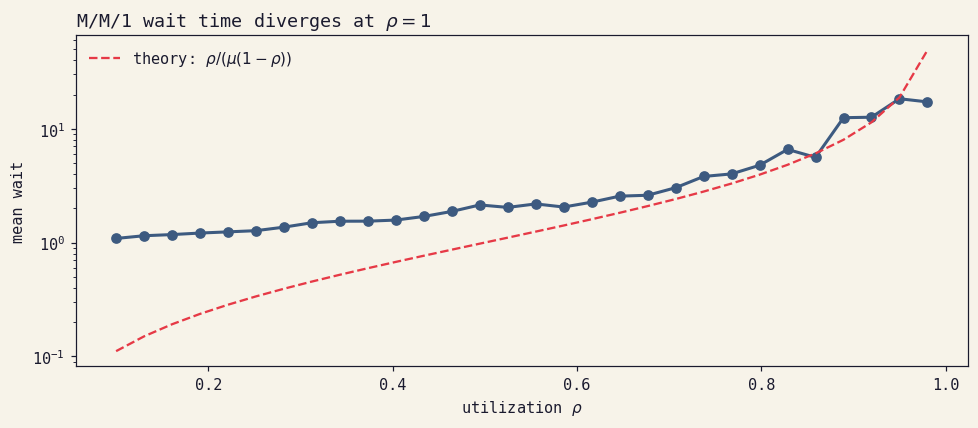

In [14]:
# Plot mean wait vs rho. This is the shape of the cliff.
rhos = np.linspace(0.1, 0.98, 30)
means = []
for rho in rhos:
    w, _ = simulate_server(rho * MU, MU, duration=5000, cap=None)
    means.append(w.mean() if len(w) else np.nan)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(rhos, means, "o-", color=PALETTE["indigo"], lw=2)
# Theoretical M/M/1 mean wait: rho / (mu (1 - rho)) for time in system minus service.
theory = rhos / (MU * (1 - rhos))
ax.plot(rhos, theory, "--", color=PALETTE["rose"], lw=1.5, label="theory: $\\rho/(\\mu(1-\\rho))$")
ax.set_xlabel("utilization $\\rho$")
ax.set_ylabel("mean wait")
ax.set_title("M/M/1 wait time diverges at $\\rho = 1$", loc="left")
ax.set_yscale("log")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The simulator tracks theory well up to about $\rho = 0.95$, where the finite simulation window starts bounding the queue. The real curve is an asymptote — theoretically infinite at $\rho = 1$. Now let's contrast an overloaded server with and without an admission cap.

overload, no cap : p50  584.07  p99   937.11  rejects 0
overload, cap=20 : p50    8.98  p99    22.62  rejects 5959


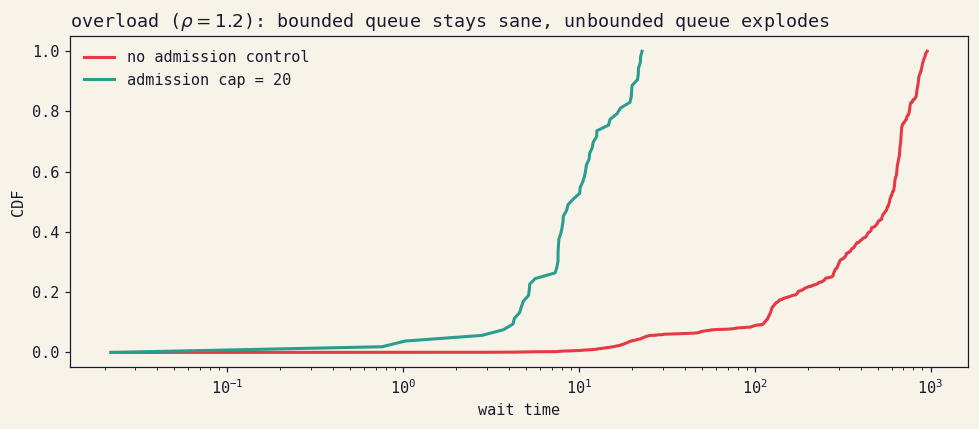

In [15]:
w_no_cap, rej_no  = simulate_server(1.2 * MU, MU, duration=5000, cap=None)
w_cap,    rej_cap = simulate_server(1.2 * MU, MU, duration=5000, cap=20)

print(f"overload, no cap : p50 {np.median(w_no_cap):7.2f}  p99 {np.percentile(w_no_cap, 99):8.2f}  rejects {rej_no}")
print(f"overload, cap=20 : p50 {np.median(w_cap):7.2f}  p99 {np.percentile(w_cap, 99):8.2f}  rejects {rej_cap}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.sort(w_no_cap), np.linspace(0, 1, len(w_no_cap)),
        color=PALETTE["rose"], lw=2, label="no admission control")
ax.plot(np.sort(w_cap), np.linspace(0, 1, len(w_cap)),
        color=PALETTE["teal"], lw=2, label="admission cap = 20")
ax.set_xlabel("wait time")
ax.set_ylabel("CDF")
ax.set_xscale("log")
ax.set_title("overload ($\\rho = 1.2$): bounded queue stays sane, unbounded queue explodes",
             loc="left")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The rose curve (no cap) is flat for most of the plot — nearly everyone is waiting a very long time. The teal curve (cap=20) stays snug against the left axis because the scheduler rejects overflow instead of letting it accumulate. The rejected requests become somebody else's problem (retry with backoff, shed to a different replica, show a spinner) but the served requests get their SLO.

In practice, production servers compute something like $\hat\rho$ from a rolling window and route based on it. vLLM exposes `max_num_seqs`, `max_num_batched_tokens`, and a waiting queue length — those together *are* admission control.


---
## 28e — Priority scheduling: not every request is equal

Free users and premium users hit the same GPU. A fair FIFO queue treats them identically, which is correct and also not what the business wants. Priority scheduling gives premium users a latency multiplier — usually weighted fair queueing (WFQ) — so they move up the queue but don't entirely starve free users.

We'll simulate two tiers: 80% free, 20% premium. Under priority, premium requests get served before free ones whenever both are waiting.

In [16]:
def simulate_priority(arrival_rate, service_rate, duration=3000, priority=False, premium_frac=0.2):
    rng = np.random.default_rng(13)
    t = 0.0
    # queues[0] = premium, queues[1] = free
    queues = [deque(), deque()]
    waits_p = []
    waits_f = []
    server_free_at = 0.0

    events = []
    while t < duration:
        t += rng.exponential(1.0 / arrival_rate)
        if t >= duration:
            break
        tier = 0 if rng.random() < premium_frac else 1
        events.append((t, tier))

    ptr = 0
    def next_arrival():
        nonlocal ptr
        if ptr >= len(events):
            return None
        a = events[ptr]; ptr += 1
        return a

    cur = next_arrival()
    while cur is not None or queues[0] or queues[1]:
        # If the server is free and we have work, serve it.
        if (queues[0] or queues[1]) and server_free_at <= (cur[0] if cur else 1e18):
            if priority:
                q = 0 if queues[0] else 1
            else:
                q = 0 if (queues[0] and (not queues[1] or queues[0][0] <= queues[1][0])) else 1
            arrival_t = queues[q].popleft()
            start = max(arrival_t, server_free_at)
            svc = rng.exponential(1.0 / service_rate)
            done = start + svc
            (waits_p if q == 0 else waits_f).append(done - arrival_t)
            server_free_at = done
        else:
            if cur is None:
                break
            queues[cur[1]].append(cur[0])
            cur = next_arrival()

    return np.array(waits_p), np.array(waits_f)

fair_p, fair_f = simulate_priority(0.85, 1.0, duration=4000, priority=False)
pri_p,  pri_f  = simulate_priority(0.85, 1.0, duration=4000, priority=True)

print(f"fair   : premium p50 {np.median(fair_p):5.2f}  p99 {np.percentile(fair_p,99):6.2f}   "
      f"free p50 {np.median(fair_f):5.2f}  p99 {np.percentile(fair_f,99):6.2f}")
print(f"priority: premium p50 {np.median(pri_p):5.2f}  p99 {np.percentile(pri_p,99):6.2f}   "
      f"free p50 {np.median(pri_f):5.2f}  p99 {np.percentile(pri_f,99):6.2f}")

fair   : premium p50  4.24  p99  21.81   free p50  4.04  p99  22.04
priority: premium p50  1.70  p99   6.44   free p50  4.39  p99  27.00


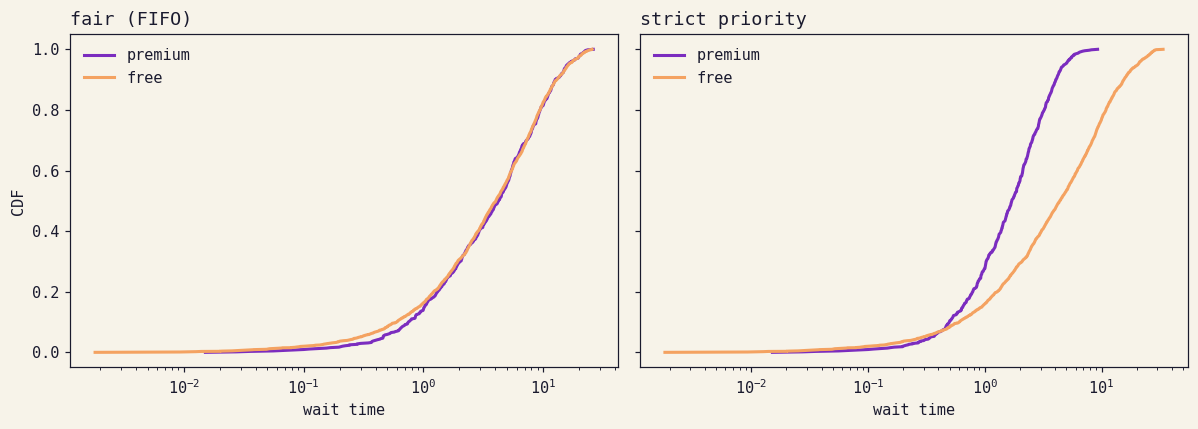

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (pp, ff, title) in zip(axes, [(fair_p, fair_f, "fair (FIFO)"),
                                       (pri_p, pri_f, "strict priority")]):
    ax.plot(np.sort(pp), np.linspace(0, 1, len(pp)),
            color=PALETTE["plum"],  lw=2, label="premium")
    ax.plot(np.sort(ff), np.linspace(0, 1, len(ff)),
            color=PALETTE["amber"], lw=2, label="free")
    ax.set_xlabel("wait time")
    ax.set_title(title, loc="left")
    ax.set_xscale("log")
    ax.legend(frameon=False)
axes[0].set_ylabel("CDF")
plt.tight_layout()
plt.show()

Left: premium and free are indistinguishable — fairness. Right: premium snaps to the left (faster), free drifts right (slower). You've given premium users a better SLO at free users' expense.

Strict priority is the hammer. Real systems use **weighted fair queueing** (e.g., DRR — deficit round robin) so free users don't fully starve, or put premium on its own fleet with guaranteed capacity. The simulation above is the educational version, not the "please paste this into prod" version.


---
## 28f — Little's law and the throughput/latency frontier

Little's law is one of the most useful laws in all of queueing theory, and it's easy:

$$
L = \lambda W
$$

- $L$ = average number of items in the system (in-flight requests)
- $\lambda$ = arrival rate (requests per unit time)
- $W$ = average time in the system (latency)

For LLM serving, rearrange it: if your engine can sustain $X$ tokens/sec throughput and each request takes on average $W$ seconds, the number of concurrent in-flight requests is $L = X \cdot W / \bar\ell$ where $\bar\ell$ is the mean tokens per request. That gives you a back-of-envelope sanity check for how many concurrent users a single replica can hold.

The more practical view is the **throughput-latency frontier**: sweep load from low to high, and plot throughput on the x-axis vs latency on the y-axis. You get a hockey stick. The flat part is "you have capacity, use it." The cliff is where the queue explodes.


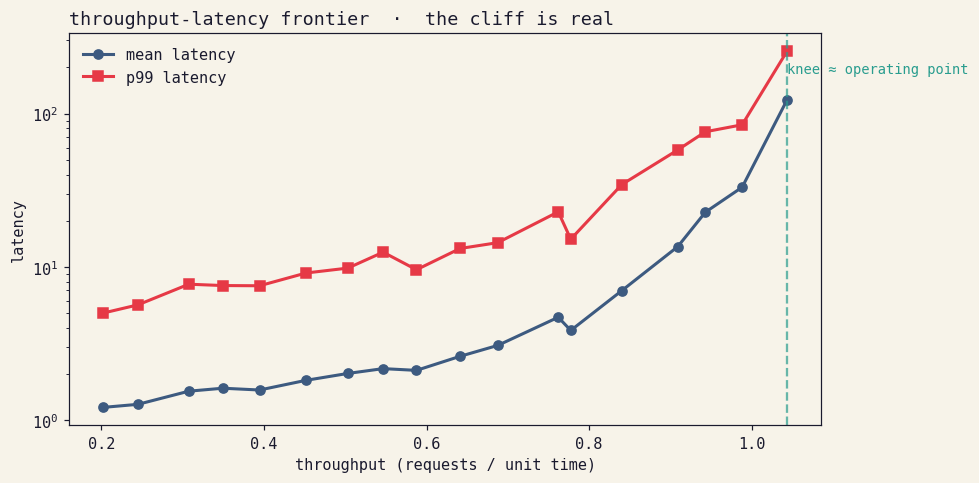

In [18]:
# Sweep arrival rate, measure throughput (served / duration) and mean latency.
loads = np.linspace(0.2, 1.05, 18)
throughputs = []
mean_lats = []
p99_lats = []
for rho in loads:
    w, _ = simulate_server(rho * MU, MU, duration=5000, cap=None)
    throughputs.append(len(w) / 5000.0)
    mean_lats.append(w.mean())
    p99_lats.append(np.percentile(w, 99))

throughputs = np.array(throughputs)
mean_lats   = np.array(mean_lats)
p99_lats    = np.array(p99_lats)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(throughputs, mean_lats, "o-", color=PALETTE["indigo"], lw=2, label="mean latency")
ax.plot(throughputs, p99_lats,  "s-", color=PALETTE["rose"],   lw=2, label="p99 latency")
ax.set_xlabel("throughput (requests / unit time)")
ax.set_ylabel("latency")
ax.set_yscale("log")
ax.set_title("throughput-latency frontier  ·  the cliff is real", loc="left")
ax.legend(frameon=False)

# Mark the "knee" — where the derivative starts exploding.
knee_idx = np.argmax(np.gradient(np.log(mean_lats)))
ax.axvline(throughputs[knee_idx], color=PALETTE["teal"], ls="--", lw=1.5, alpha=0.7)
ax.text(throughputs[knee_idx], mean_lats[knee_idx]*1.5,
        "knee ≈ operating point",
        color=PALETTE["teal"], fontsize=9)
plt.tight_layout()
plt.show()

Operators live on that knee. Push past it and p99 runs to the moon; back off from it and you're wasting capacity. Capacity planning for LLM serving is mostly the art of picking a point on that curve that your SLO can afford.


---
## 28g — Break-things demo: what happens when you turn scheduling off

Two knockout experiments:

1. Replay the 40-request workload with continuous batching **disabled**. Measure the throughput hit and the grey area.
2. Replay a ramp of increasing load with admission control **disabled**. Watch the latency-to-infinity cliff.

These are the two "what could possibly go wrong" demos that make you appreciate scheduling as a *feature* rather than plumbing.


In [19]:
# Experiment 1 — continuous batching off.
static_useful = (static_big == 1).sum()
static_total  = static_big.size
cont_useful   = (cont_big  > 0).sum()
cont_total    = cont_big.size

print("experiment 1 — continuous batching OFF:")
print(f"  static wall    : {static_big.shape[1]} steps")
print(f"  static useful  : {static_useful}/{static_total}  ({static_useful/static_total:.1%})")
print(f"  cont wall      : {cont_big.shape[1]} steps")
print(f"  cont useful    : {cont_useful}/{cont_total}  ({cont_useful/cont_total:.1%})")
tokens = big_lens.sum()
static_tput = tokens / static_big.shape[1]
cont_tput   = tokens / cont_big.shape[1]
print(f"  static tput    : {static_tput:.2f} tok/step")
print(f"  cont   tput    : {cont_tput:.2f} tok/step")
print(f"  throughput hit : {100*(1 - static_tput/cont_tput):.1f}% worse with batching off")

experiment 1 — continuous batching OFF:
  static wall    : 1600 steps
  static useful  : 5985/16000  (37.4%)
  cont wall      : 1045 steps
  cont useful    : 5985/10450  (57.3%)
  static tput    : 3.74 tok/step
  cont   tput    : 5.73 tok/step
  throughput hit : 34.7% worse with batching off


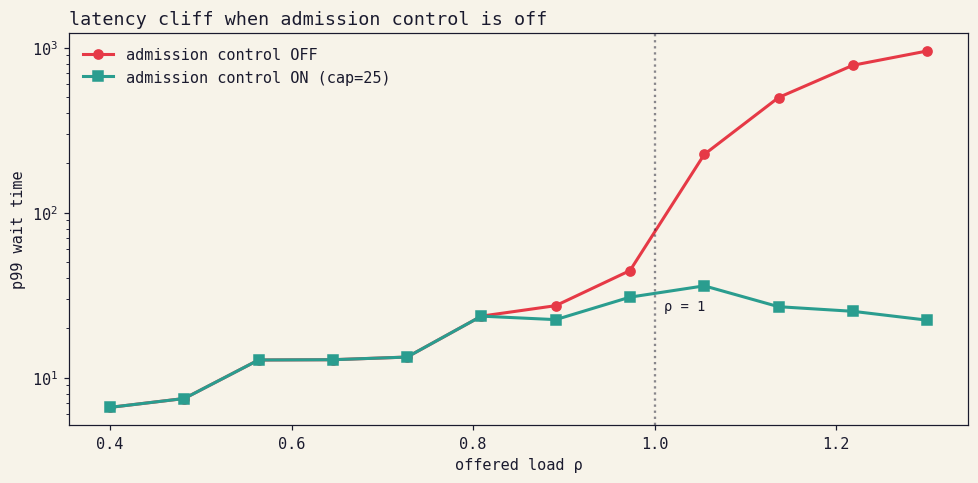

In [20]:
# Experiment 2 — admission control off, ramp load.
ramps = np.linspace(0.4, 1.3, 12)
p99_with, p99_without = [], []
for rho in ramps:
    w_off, _ = simulate_server(rho * MU, MU, duration=3000, cap=None)
    w_on,  _ = simulate_server(rho * MU, MU, duration=3000, cap=25)
    p99_without.append(np.percentile(w_off, 99) if len(w_off) else np.nan)
    p99_with.append(np.percentile(w_on, 99)    if len(w_on)  else np.nan)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ramps, p99_without, "o-", color=PALETTE["rose"],  lw=2, label="admission control OFF")
ax.plot(ramps, p99_with,    "s-", color=PALETTE["teal"],  lw=2, label="admission control ON (cap=25)")
ax.set_yscale("log")
ax.axvline(1.0, color=PALETTE["ink"], ls=":", alpha=0.5)
ax.text(1.01, ax.get_ylim()[0]*5, "ρ = 1", fontsize=9, color=PALETTE["ink"])
ax.set_xlabel("offered load ρ")
ax.set_ylabel("p99 wait time")
ax.set_title("latency cliff when admission control is off", loc="left")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Past $\rho = 1.0$ the no-admission-control curve launches toward the ceiling. Admission control caps p99 at a finite value — not great, not terrible — and keeps the server responsive for the requests it *does* admit.

Two rules of thumb from this module:

- **Never run a serving tier above 85-90% sustained utilization.** Bursts will push you over 100% and you need the margin.
- **Never let your queue grow unbounded.** A request that sits for 30 seconds is already dead to the user who sent it; serving it is negative-value work.


---
## Checkpoint (5 questions)

1. In static batching, you have a batch of 16 requests where 15 want 100 tokens and 1 wants 1600. Roughly what fraction of GPU cycles are useful work?

2. Continuous batching improves throughput "2-8x with zero accuracy change." Why zero accuracy change? What exactly is different in the compute?

3. You have a workload where every prompt is short (20 tokens) and every decode is long (2000 tokens). Will chunked prefill help? Why or why not?

4. Your server is running at $\rho = 0.8$. Traffic doubles for ten minutes. Assume no admission control. What happens in the ten minutes? What happens after the burst ends?

5. Little's law says $L = \lambda W$. You measure $\lambda = 50$ requests/sec and $L = 200$ in-flight. What is your average end-to-end latency?


<details>
<summary>answers</summary>

1. Useful = $15 \times 100 + 1 \times 1600 = 3100$. Total = $16 \times 1600 = 25600$. Ratio ≈ **12%**. The one long request wastes 88% of the batch.
2. Attention math is identical — the scheduler only decides *which* tokens for *which* requests are in the same forward pass. Weights, activations, and outputs per token are untouched. It's scheduling, not compute.
3. Not much. Chunked prefill shines when long prompts stall decodes. Here, prefill is negligible and decode dominates. You'd focus on raw decode batch size, KV cache compression (Module 14), speculative decoding (Module 25).
4. During the burst, the queue grows without bound and latency climbs every second. After the burst, the queue has to drain — so latency stays elevated until the backlog is gone. Tail users from the burst can see many-multiples-of-normal wait even though the server is "fine" again.
5. $W = L/\lambda = 200/50 = $ **4 seconds** average in-system time.

</details>


---
## Bridge to Module 29

We assumed a single GPU this whole module. The scheduler packs requests into slots, and slots are seats on one device. Real production servers are almost never one GPU — they're tensor-parallel across 4 or 8 GPUs per replica, pipeline-parallel across stages, and there are dozens of replicas behind a load balancer.

Scheduling across *one* GPU gives you continuous batching. Scheduling across *many* GPUs gives you pipeline bubbles, all-reduce synchronization points, and a whole new class of "who waits for whom" questions. That's Module 29.
